In [1]:
import torch
import matplotlib.pyplot as plt
from data.wm_task import TaskConfig, SternbergWM
from models.rnn_torch import SimpleRNNTorch


In [5]:
batch = task.sample_batch()
print(type(batch))
print(batch)


<class 'dict'>
{'X': array([[[1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.]],

       [[1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 1., 0., 1.],
        [0., 0., 0., ..., 1., 0., 1.],
        [0., 0., 0., ..., 1., 0., 1.]],

       [[1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 1., ..., 0., 0., 1.],
        [0., 0., 1., ..., 0., 0., 1.],
        [0., 0., 1., ..., 0., 0., 1.]],

       ...,

       [[1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 1., 0., 1.],
        [0., 0., 0., ..., 1., 0., 1.],
        [0.

In [2]:
cfg = TaskConfig(batch_size=128, n_identities=6, max_load=3, T_probe=30)
task = SternbergWM(cfg)
batch = task.sample_batch()
print(batch['X'].shape, batch['Y'].shape)  # [B, T, I], [B, T, O]


(128, 324, 9) (128, 324, 2)


In [3]:
model = SimpleRNNTorch(
    input_dim=batch['X'].shape[-1],
    hidden_dim=256,
    output_dim=2
)
logits, h = model(torch.tensor(batch['X'], dtype=torch.float32))
print(logits.shape)


torch.Size([128, 324, 2])


AttributeError: 'TaskConfig' object has no attribute 'T_total'

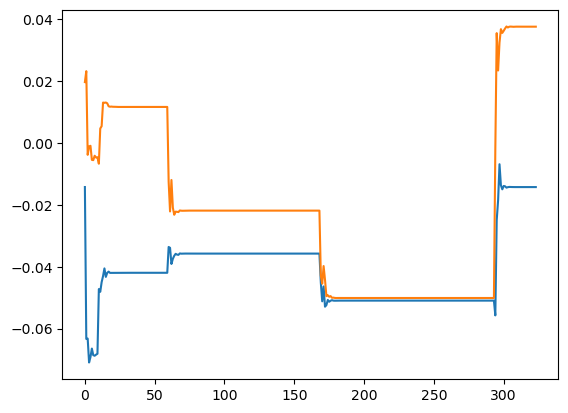

In [11]:
plt.plot(logits[0].detach().numpy())
plt.axvline(cfg.T_total - cfg.T_probe, color='r', linestyle='--')  # probe onset
plt.title("Output logits for one trial")
plt.show()


In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

for step in range(1000):
    batch = task.sample_batch()
    x = torch.tensor(batch['X'], dtype=torch.float32)
    y = torch.tensor(batch['Y'][:, -1, :].argmax(-1), dtype=torch.long)  # 只看probe时刻
    
    logits, _ = model(x)
    loss = loss_fn(logits[:, -1, :], y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 100 == 0:
        print(f"Step {step}, Loss: {loss.item():.4f}")


Step 0, Loss: 0.6924
Step 100, Loss: 0.6975
Step 200, Loss: 0.6924
Step 300, Loss: 0.6948


KeyboardInterrupt: 

In [2]:
import torch
from data.wm_task import TaskConfig, SternbergWM
from models.rnn_torch import GRUTorch  # 你把类放到这个文件里即可

device = "cuda" if torch.cuda.is_available() else "cpu"
cfg = TaskConfig(batch_size=128, n_identities=6, max_load=3, T_probe=30)
task = SternbergWM(cfg)

# 选一个：GRU 或 LSTM
model = GRUTorch(input_dim=cfg.n_inputs(), hidden_dim=256, output_dim=2).to(device)
# model = LSTMTorch(input_dim=cfg.n_inputs(), hidden_dim=256, output_dim=2).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
import torch.nn.functional as F

def loss_on_probe(logits, targets, T_probe):
    B, T, _ = logits.shape
    s = slice(T - T_probe, T)
    p = F.softmax(logits[:, s, :], dim=-1)  # 评估/回归时才softmax
    y = targets[:, s, :]
    return F.mse_loss(p, y)

for step in range(1, 1001):
    batch = task.sample_batch()
    Xb = torch.from_numpy(batch["X"]).to(device)
    Yb = torch.from_numpy(batch["Y"]).to(device)

    opt.zero_grad()
    logits, states = model(Xb)
    loss = loss_on_probe(logits, Yb, cfg.T_probe)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()

    if step % 100 == 0:
        T = batch["meta"]["T_total"]; s = slice(T - cfg.T_probe, T)
        with torch.no_grad():
            p = torch.softmax(logits[:, s, :], dim=-1).mean(dim=1)
            y_true = Yb[:, s, :].mean(dim=1).argmax(dim=-1)
            acc = (p.argmax(dim=-1) == y_true).float().mean().item()
        print(f"step {step:4d} | loss {loss.item():.4f} | acc {acc:.3f}")


KeyboardInterrupt: 

In [16]:
logits[:, -1, :].shape

torch.Size([128, 2])